## Simple Iris Classifier	
Using the Iris dataset from scikit-learn, split the dataset into training and testing sets. Train a Decision Tree classifier, evaluate accuracy, and explain the confusion matrix.
Expected Deliverables: Training code, evaluation metrics, and a short explanation


Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

Load the Iris Dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nDataset Shape:")
print(X.shape)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
(150, 4)


Split into Training and Testing Sets

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


Train Decision Tree Classifier

In [4]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


Make Predictions

In [5]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 2 1 1 0 1 0 0 2 1]


Calculate Accuracy

In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9667


Classification Report

In [7]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Confusion Matrix

In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


Visualize Confusion Matrix

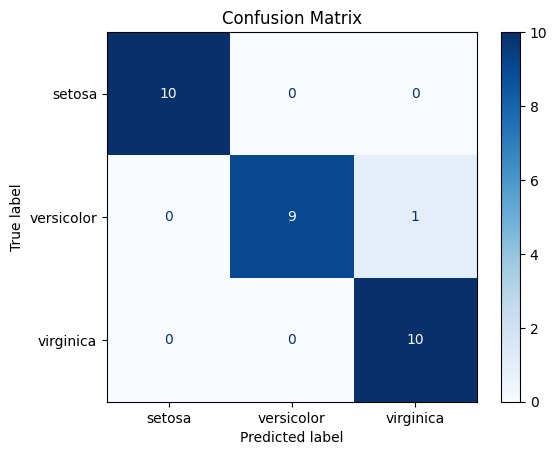

In [9]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

Visualize Decision Tree

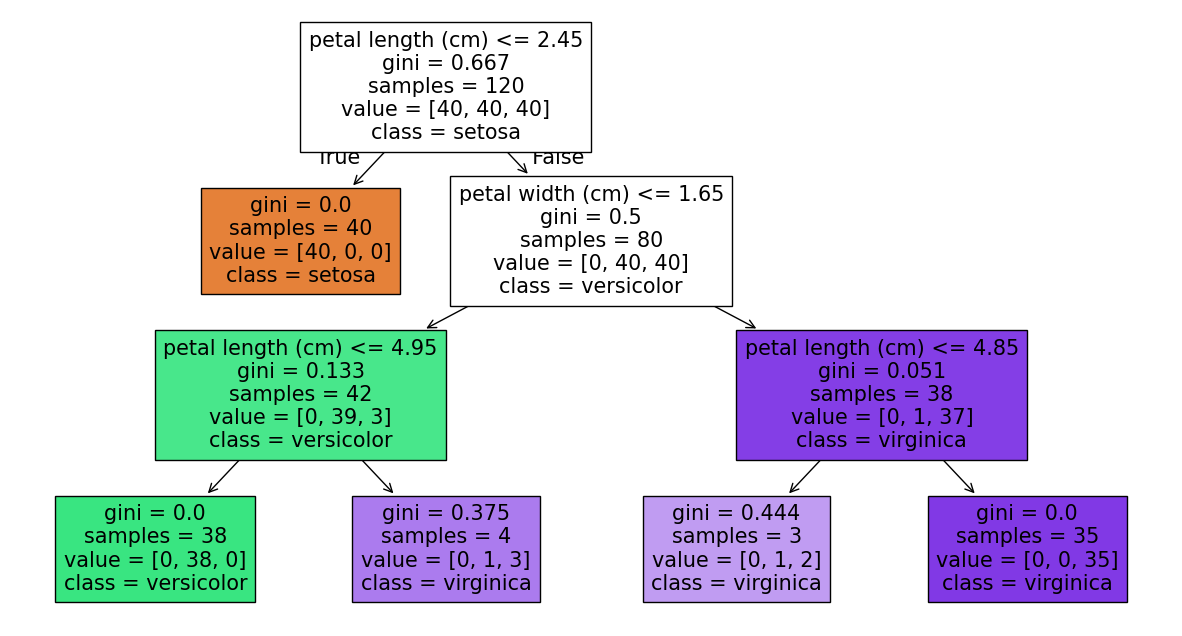

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()